In [8]:
# First things first — let's make sure every library we need is installed.
# surprise is the go-to library for collaborative-filtering algorithms (SVD, KNN, etc.)
# If you're running this on Kaggle/Colab these installs happen in seconds.

import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

install("scikit-surprise")   # collaborative filtering toolkit
install("matplotlib")
install("seaborn")
install("pandas")
install("numpy")
install("scipy")
install("tqdm")

In [9]:
# Standard data-science imports — nothing exotic here.
import os
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tqdm import tqdm

# surprise lives in the 'surprise' namespace
from surprise import (
    Dataset, Reader,
    SVD, SVDpp, NMF,
    KNNBasic, KNNWithMeans, KNNWithZScore,
    accuracy
)
from surprise.model_selection import train_test_split, cross_validate, GridSearchCV

# reproducibility — set a seed so results are the same every run
SEED = 42
np.random.seed(SEED)

print(" All libraries loaded successfully!")


 All libraries loaded successfully!


# 1. Data Loading
The full Netflix Prize dataset  has **100 million+ ratings** spread across four `.txt` files ( `combined_data_1.txt` through `combined_data_4.txt` ) plus a `movie_titles.csv` .

**Note:** Since the full dataset is enormous (~2 GB), we load a manageable subset (configurable via `MAX_ROWS` ). The problem statement explicitly allows this: "Participants are encouraged to use appropriate subsets of the data if computational constraints prevent training on the full dataset."







In [10]:
# ── Configuration ──────────────────────────────────────────────────────────────
# Change MAX_ROWS to None if you have the RAM for the full 100 M+ rating dataset.
DATA_DIR  = "/content/netflix-prize-data"   # adjust if running locally
MAX_ROWS  = 1_000_000                            # ~1 % of the full dataset

# --- FIX: Move files from /content/ to DATA_DIR and rename ---
import glob
import shutil
import os
import pandas as pd

if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)
    print(f"Directory '{DATA_DIR}' created.")

# Find files in /content/ that look like combined_data_*[1].txt and move/rename them
for file_path in glob.glob('/content/combined_data_*[1].txt'):
    new_file_name = os.path.basename(file_path).replace('[1]', '')
    destination_path = os.path.join(DATA_DIR, new_file_name)
    shutil.move(file_path, destination_path)
    print(f"Moved and renamed '{os.path.basename(file_path)}' to '{destination_path}'")

# Move any other combined_data_*.txt files that might be directly in /content/
for file_path in glob.glob('/content/combined_data_*.txt'):
    if not os.path.exists(os.path.join(DATA_DIR, os.path.basename(file_path))):
        shutil.move(file_path, os.path.join(DATA_DIR, os.path.basename(file_path)))
        print(f"Moved '{os.path.basename(file_path)}' to '{DATA_DIR}'")
# ──────────────────────────────────────────────────────────────────────────────

# ── Parser ──────────────────────────────────────────────────────────────────────
def load_netflix_data(data_dir: str, max_rows: int = None) -> pd.DataFrame:
    """
    Netflix Prize files look like this:
        1234:          <- this line means: the next ratings belong to movie 1234
        UserID,Rating,Date
        UserID,Rating,Date
        ...
    We parse that slightly unusual format and return a tidy DataFrame.
    """
    records    = []
    movie_id   = None
    rows_seen  = 0

    files = sorted([
        os.path.join(data_dir, f)
        for f in os.listdir(data_dir)
        if f.startswith("combined_data") and f.endswith(".txt")
    ])

    if not files:
        raise FileNotFoundError(
            f"No 'combined_data*.txt' files found in '{data_dir}'."

            "Please download the Netflix Prize dataset from Kaggle and place it there."
        )

    for filepath in files:
        with open(filepath, "r") as fh:
            for line in fh:
                line = line.strip()
                if not line:
                    continue

                # A line ending with ':' marks a new movie block
                if line.endswith(":"):
                    movie_id = int(line[:-1])
                else:
                    parts = line.split(",")
                    if len(parts) == 3:
                        user_id, rating, date = parts
                        records.append((int(user_id), movie_id, int(rating), date))
                        rows_seen += 1
                        if max_rows and rows_seen >= max_rows:
                            print(f"  Reached MAX_ROWS={max_rows:,} — stopping early.")
                            df = pd.DataFrame(records, columns=["user_id","movie_id","rating","date"])
                            df["date"] = pd.to_datetime(df["date"], format='mixed')
                            return df

    df = pd.DataFrame(records, columns=["user_id","movie_id","rating","date"])
    df["date"] = pd.to_datetime(df["date"], format='mixed')
    return df


print("Loading data …")
df_ratings = load_netflix_data(DATA_DIR, max_rows=MAX_ROWS)
print(f"Loaded {len(df_ratings):,} ratings.")
df_ratings.head()

Moved and renamed 'combined_data_1.txt' to '/content/netflix-prize-data/combined_data_1.txt'
Moved 'combined_data_3.txt' to '/content/netflix-prize-data'
Moved 'combined_data_4.txt' to '/content/netflix-prize-data'
Moved 'combined_data_2.txt' to '/content/netflix-prize-data'
Loading data …
  Reached MAX_ROWS=1,000,000 — stopping early.
Loaded 1,000,000 ratings.


,user_id,movie_id,rating,date
0,591098,NaN,2,2005-08-08
1,802876,NaN,5,2005-08-09
2,1681947,NaN,3,2005-08-09
3,2603551,NaN,3,2005-08-10
4,1002025,NaN,4,2005-08-11


In [11]:
import shutil
import os

# ── Movie Titles ───────────────────────────────────────────────────────────────
# movie_titles.csv columns: MovieID, YearOfRelease, Title
# Some titles have commas in them, so we use a slightly careful read.

# Define the expected path for movie_titles.csv
movie_titles_path = os.path.join(DATA_DIR, "movie_titles.csv")

# Check if movie_titles[1].csv exists in /content/ and move it if necessary
source_csv_path = "/content/movie_titles.csv"
if os.path.exists(source_csv_path) and not os.path.exists(movie_titles_path):
    shutil.move(source_csv_path, movie_titles_path)
    print(f"Moved '{os.path.basename(source_csv_path)}' to '{movie_titles_path}'")

df_movies = pd.read_csv(
    movie_titles_path,
    encoding="latin-1",        # the file has some non-UTF8 characters
    header=None,
    names=["movie_id", "year", "title"],
    on_bad_lines="skip"        # a handful of malformed lines exist
)

print(f"Movie catalogue: {len(df_movies):,} movies")
df_movies.head(10)

Movie catalogue: 17,434 movies


,movie_id,year,title
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
5,6,1997.0,Sick
6,7,1992.0,8 Man
7,8,2004.0,What the #$*! Do We Know!?
8,9,1991.0,Class of Nuke 'Em High 2
9,10,2001.0,Fighter


## 2. Exploratory Data Analysis (EDA)

Good EDA is the foundation of any ML project — it tells us what the data looks like
before we start modelling, and it surfaces interesting patterns that can inform our
modelling choices.

We'll look at:
- **Rating distribution** — do users tend to rate generously or harshly?
- **User activity** — power users vs occasional raters
- **Movie popularity** — blockbusters vs niche films
- **Temporal trends** — has rating behaviour changed over time?
- **Data sparsity** — how dense is the user–item matrix?

In [12]:
# ── Basic Stats ────────────────────────────────────────────────────────────────
print("=== Dataset at a glance ===")
print(f"Total ratings  : {len(df_ratings):>12,}")
print(f"Unique users   : {df_ratings['user_id'].nunique():>12,}")
print(f"Unique movies  : {df_ratings['movie_id'].nunique():>12,}")
print(f"Rating range   : {df_ratings['rating'].min()} – {df_ratings['rating'].max()}")
print(f"Date range     : {df_ratings['date'].min().date()} → {df_ratings['date'].max().date()}")
print()
print(df_ratings.describe())


=== Dataset at a glance ===
Total ratings  :    1,000,000
Unique users   :      282,689
Unique movies  :          277
Rating range   : 1 – 5
Date range     : 1999-12-09 → 2005-12-31

            user_id       movie_id          rating  \
count  1.000000e+06  986493.000000  1000000.000000   
mean   1.323875e+06     449.523555        3.635936   
min    6.000000e+00       1.000000        1.000000   
25%    6.626435e+05      48.000000        3.000000   
50%    1.320119e+06     143.000000        4.000000   
75%    1.986816e+06     894.000000        4.000000   
max    2.649429e+06     967.000000        5.000000   
std    7.646188e+05     417.940348        1.070707   

                                date  
count                        1000000  
mean   2004-10-26 23:38:52.166399232  
min              1999-12-09 00:00:00  
25%              2004-06-01 00:00:00  
50%              2005-02-06 00:00:00  
75%              2005-07-03 00:00:00  
max              2005-12-31 00:00:00  
std               

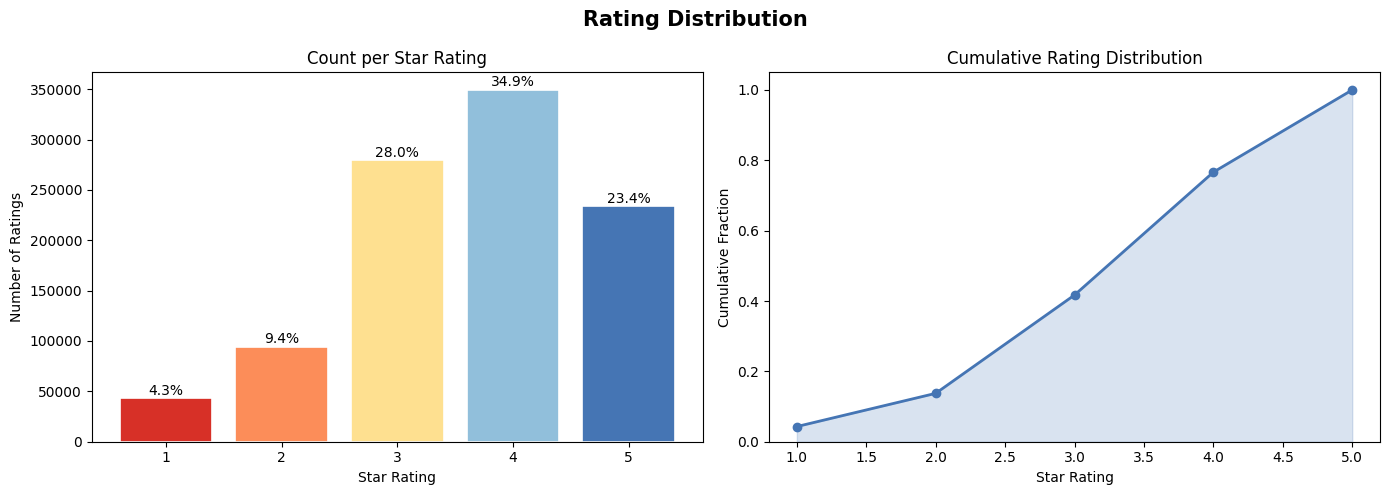

Mean rating : 3.636
Median      : 4.0


In [13]:
# ── 1. Rating Distribution ─────────────────────────────────────────────────────
# Are most people generous raters (lots of 4s and 5s) or critical?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Rating Distribution", fontsize=15, fontweight="bold")

rating_counts = df_ratings["rating"].value_counts().sort_index()

# Bar chart
axes[0].bar(rating_counts.index, rating_counts.values,
            color=["#d73027","#fc8d59","#fee090","#91bfdb","#4575b4"],
            edgecolor="white", linewidth=1.2)
axes[0].set_xlabel("Star Rating")
axes[0].set_ylabel("Number of Ratings")
axes[0].set_title("Count per Star Rating")
for x, y in zip(rating_counts.index, rating_counts.values):
    axes[0].text(x, y + rating_counts.max()*0.01, f"{y/len(df_ratings)*100:.1f}%",
                 ha="center", fontsize=10)

# Cumulative distribution
cumulative = rating_counts.cumsum() / rating_counts.sum()
axes[1].plot(cumulative.index, cumulative.values, "o-", color="#4575b4", linewidth=2)
axes[1].fill_between(cumulative.index, cumulative.values, alpha=0.2, color="#4575b4")
axes[1].set_xlabel("Star Rating")
axes[1].set_ylabel("Cumulative Fraction")
axes[1].set_title("Cumulative Rating Distribution")
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("eda_rating_distribution.png", dpi=150)
plt.show()

print(f"Mean rating : {df_ratings['rating'].mean():.3f}")
print(f"Median      : {df_ratings['rating'].median():.1f}")

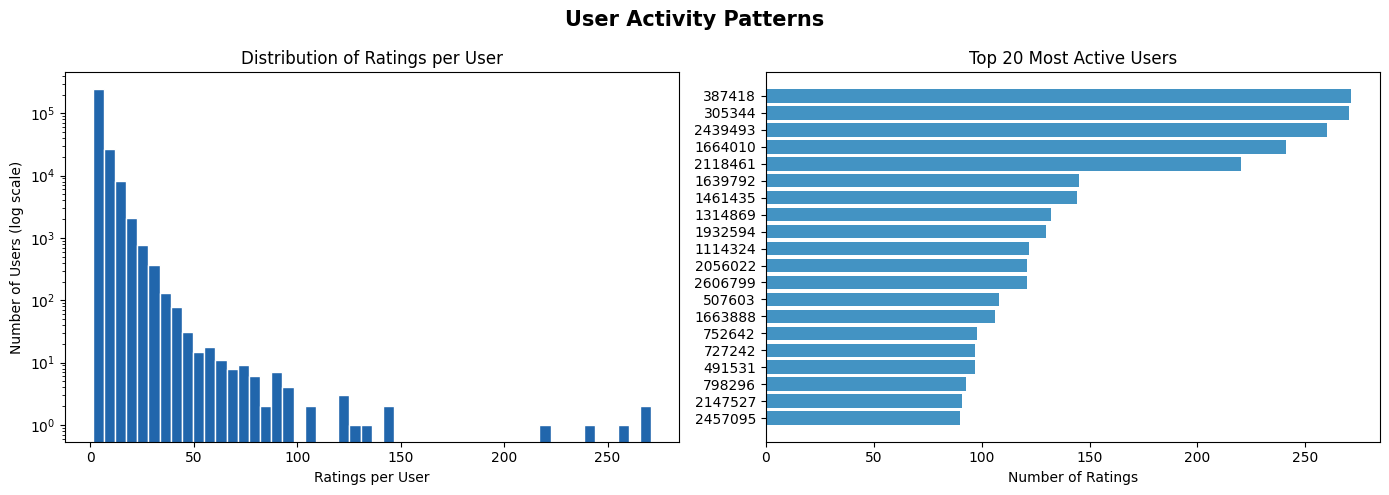

Average ratings per user : 3.5
Median ratings per user  : 2
Top 1% users account for : 7.5% of all ratings


In [14]:
# ── 2. User Activity (long-tail behaviour) ─────────────────────────────────────
# Classic long-tail: a small fraction of users account for most ratings.

user_activity = df_ratings.groupby("user_id")["rating"].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("User Activity Patterns", fontsize=15, fontweight="bold")

# Histogram — most users rate very few movies
axes[0].hist(user_activity, bins=50, color="#2166ac", edgecolor="white", log=True)
axes[0].set_xlabel("Ratings per User")
axes[0].set_ylabel("Number of Users (log scale)")
axes[0].set_title("Distribution of Ratings per User")

# Top-20 most active users
top_users = user_activity.head(20)
axes[1].barh(top_users.index.astype(str), top_users.values, color="#4393c3")
axes[1].invert_yaxis()
axes[1].set_xlabel("Number of Ratings")
axes[1].set_title("Top 20 Most Active Users")

plt.tight_layout()
plt.savefig("eda_user_activity.png", dpi=150)
plt.show()

print(f"Average ratings per user : {user_activity.mean():.1f}")
print(f"Median ratings per user  : {user_activity.median():.0f}")
print(f"Top 1% users account for : {user_activity.head(int(len(user_activity)*0.01)).sum()/len(df_ratings)*100:.1f}% of all ratings")

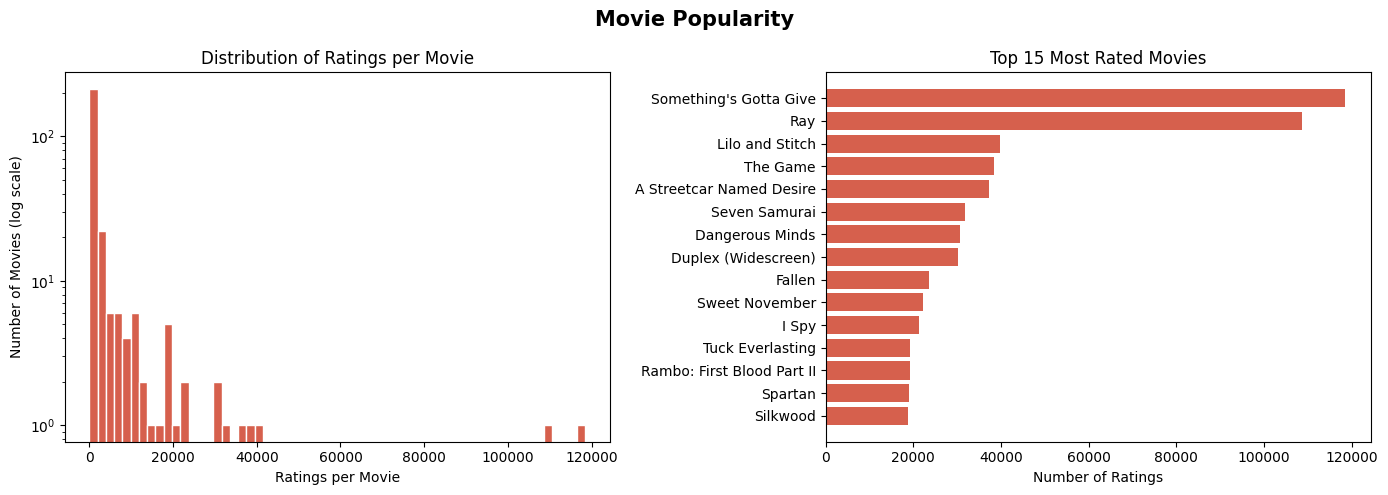

Top 10 movies by average rating (with ≥1000 ratings):
                                                title  num_ratings  avg_rating
                                        Seven Samurai        31691    4.199615
                                Sense and Sensibility        11038    4.191339
                                                  Ray       108606    4.186012
                       Aqua Teen Hunger Force: Vol. 1         6890    4.168650
                                          Invader Zim         2216    4.142599
                                I Love Lucy: Season 2         2954    4.090386
ABC Primetime: Mel Gibson's The Passion of the Christ         1854    4.071737
                                   Reno 911: Season 2         2914    4.052848
                                      Animal Crackers         4900    4.016122
                               The Jewel in the Crown         1420    3.988028


In [15]:
# ── 3. Movie Popularity ────────────────────────────────────────────────────────
# Some movies get millions of ratings; most get very few.

movie_popularity = df_ratings.groupby("movie_id")["rating"].agg(["count","mean"]).reset_index()
movie_popularity.columns = ["movie_id","num_ratings","avg_rating"]
movie_popularity = movie_popularity.merge(df_movies[["movie_id","title"]], on="movie_id", how="left")
movie_popularity = movie_popularity.sort_values("num_ratings", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Movie Popularity", fontsize=15, fontweight="bold")

# Distribution of ratings per movie
axes[0].hist(movie_popularity["num_ratings"], bins=60, color="#d6604d", edgecolor="white", log=True)
axes[0].set_xlabel("Ratings per Movie")
axes[0].set_ylabel("Number of Movies (log scale)")
axes[0].set_title("Distribution of Ratings per Movie")

# Top-15 movies by number of ratings
top_movies = movie_popularity.head(15)
axes[1].barh(top_movies["title"].fillna("Unknown"), top_movies["num_ratings"], color="#d6604d")
axes[1].invert_yaxis()
axes[1].set_xlabel("Number of Ratings")
axes[1].set_title("Top 15 Most Rated Movies")

plt.tight_layout()
plt.savefig("eda_movie_popularity.png", dpi=150)
plt.show()

print("Top 10 movies by average rating (with ≥1000 ratings):")
popular = movie_popularity[movie_popularity["num_ratings"] >= 1000]
print(popular.sort_values("avg_rating", ascending=False).head(10)[["title","num_ratings","avg_rating"]].to_string(index=False))

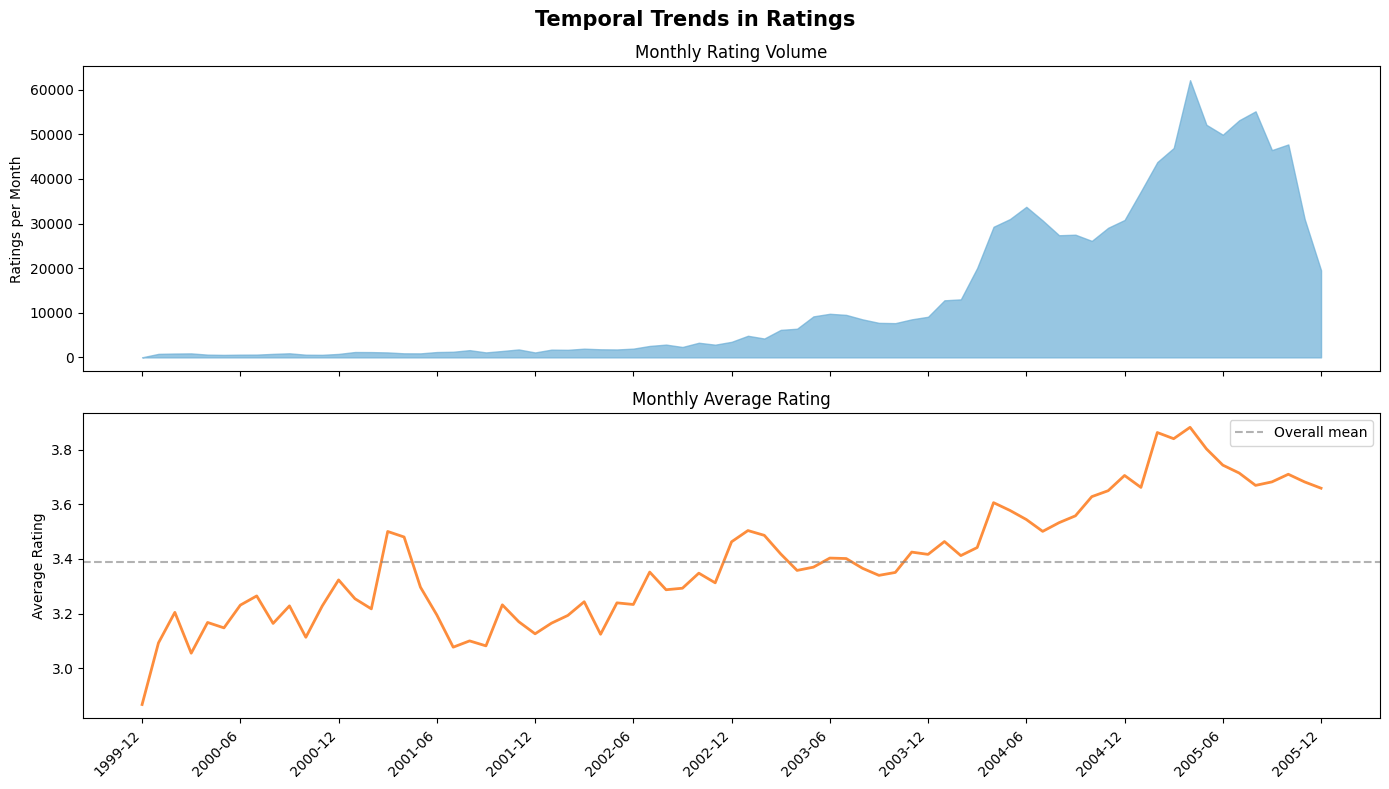

In [16]:
# ── 4. Temporal Trends ─────────────────────────────────────────────────────────
# Did rating behaviour shift over the years? The Netflix Prize data spans ~6 years.

df_ratings["year_month"] = df_ratings["date"].dt.to_period("M")
temporal = df_ratings.groupby("year_month").agg(
    num_ratings=("rating","count"),
    avg_rating =("rating","mean")
).reset_index()
temporal["year_month_str"] = temporal["year_month"].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Temporal Trends in Ratings", fontsize=15, fontweight="bold")

# Volume
axes[0].fill_between(range(len(temporal)), temporal["num_ratings"],
                     color="#6baed6", alpha=0.7)
axes[0].set_ylabel("Ratings per Month")
axes[0].set_title("Monthly Rating Volume")

# Average rating
axes[1].plot(range(len(temporal)), temporal["avg_rating"],
             color="#fd8d3c", linewidth=2)
axes[1].axhline(temporal["avg_rating"].mean(), linestyle="--", color="grey", alpha=0.6, label="Overall mean")
axes[1].set_ylabel("Average Rating")
axes[1].set_title("Monthly Average Rating")
axes[1].legend()

# X-axis ticks (every 6 months)
tick_positions = range(0, len(temporal), 6)
tick_labels = [temporal["year_month_str"].iloc[i] for i in tick_positions]
axes[1].set_xticks(list(tick_positions))
axes[1].set_xticklabels(tick_labels, rotation=45, ha="right")

plt.tight_layout()
plt.savefig("eda_temporal.png", dpi=150)
plt.show()

Users  :    282,689
Movies :        277
Ratings:  1,000,000
Possible cells in user–item matrix:      78,304,853

Matrix DENSITY  : 1.2771%
Matrix SPARSITY : 98.7229%

This is why collaborative filtering is hard — we need to infer billions of
missing preferences from a tiny fraction of observed ones.


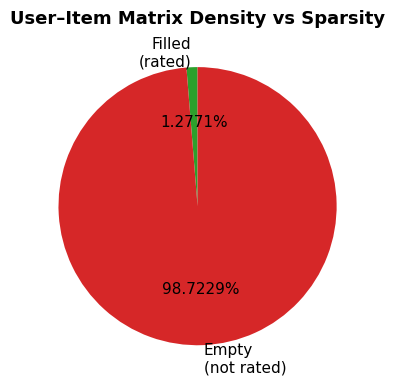

In [17]:
# ── 5. Data Sparsity
# Sparsity = fraction of the user–item matrix that is EMPTY (not rated).
# High sparsity is the defining challenge of collaborative filtering.

n_users  = df_ratings["user_id"].nunique()
n_movies = df_ratings["movie_id"].nunique()
n_filled = len(df_ratings)
n_total  = n_users * n_movies

sparsity = 1 - n_filled / n_total
density  = n_filled / n_total

print(f"Users  : {n_users:>10,}")
print(f"Movies : {n_movies:>10,}")
print(f"Ratings: {n_filled:>10,}")
print(f"Possible cells in user–item matrix: {n_total:>15,}")
print()
print(f"Matrix DENSITY  : {density*100:.4f}%")
print(f"Matrix SPARSITY : {sparsity*100:.4f}%")
print()
print("This is why collaborative filtering is hard — we need to infer billions of")
print("missing preferences from a tiny fraction of observed ones.")

# Visual summary of EDA findings
fig, ax = plt.subplots(figsize=(6, 4))
labels  = ["Filled\n(rated)", "Empty\n(not rated)"]
sizes   = [density, sparsity]
colors  = ["#2ca02c", "#d62728"]
ax.pie(sizes, labels=labels, colors=colors, autopct="%1.4f%%",
       startangle=90, textprops={"fontsize": 11})
ax.set_title("User–Item Matrix Density vs Sparsity", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_sparsity.png", dpi=150)
plt.show()

## 3. Data Preparation for Modelling

We filter out very sparse users/movies (< 5 ratings each) to reduce noise,
then build a `surprise` Dataset object which handles train/test splitting cleanly.

In [18]:
# ── Filter sparse users and movies ────────────────────────────────────────────
# Users with fewer than 5 ratings don't give us enough signal.
# Movies with fewer than 5 ratings are too obscure to recommend reliably.

MIN_RATINGS_PER_USER  = 5
MIN_RATINGS_PER_MOVIE = 5

user_counts  = df_ratings["user_id"].value_counts()
movie_counts = df_ratings["movie_id"].value_counts()

active_users  = user_counts[user_counts  >= MIN_RATINGS_PER_USER].index
active_movies = movie_counts[movie_counts >= MIN_RATINGS_PER_MOVIE].index

df_filtered = df_ratings[
    df_ratings["user_id"].isin(active_users) &
    df_ratings["movie_id"].isin(active_movies)
].copy()

print(f"Before filtering : {len(df_ratings):>10,} ratings")
print(f"After  filtering : {len(df_filtered):>10,} ratings")
print(f"Retained users   : {df_filtered['user_id'].nunique():>10,}")
print(f"Retained movies  : {df_filtered['movie_id'].nunique():>10,}")

Before filtering :  1,000,000 ratings
After  filtering :    574,289 ratings
Retained users   :     66,942
Retained movies  :        277


In [19]:
# ── Build surprise Dataset ─────────────────────────────────────────────────────
# surprise expects a DataFrame with columns [user, item, rating].
# We tell it the valid rating scale (1–5) via the Reader.

reader = Reader(rating_scale=(1, 5))

surprise_data = Dataset.load_from_df(
    df_filtered[["user_id", "movie_id", "rating"]],
    reader
)

# 80/20 train–test split — deterministic thanks to SEED
trainset, testset = train_test_split(surprise_data, test_size=0.20, random_state=SEED)

print(f"Training samples : {trainset.n_ratings:,}")
print(f"Test samples     : {len(testset):,}")
print(f"\nRating scale used: {reader.rating_scale}")


Training samples : 459,431
Test samples     : 114,858

Rating scale used: (1, 5)


## 4. Recommendation Model Development

We build **two families** of models to satisfy the mandatory Model Comparison task:

| Family | Algorithm | Core Idea |
|--------|-----------|-----------|
| **Latent Factor** | SVD (Matrix Factorisation) | Decompose the rating matrix into user & item embeddings |
| **Memory-Based** | Item-Based KNN (Collaborative Filtering) | Recommend items similar to ones the user already liked |

Both approaches are well-established and explained in the literature on the Netflix Prize.

In [20]:
# ════════════════════════════════════════════════════════════════════════════════
# MODEL A — SVD (Singular Value Decomposition / Matrix Factorisation)
# ════════════════════════════════════════════════════════════════════════════════
#
# SVD factorises the rating matrix R ≈ U × Σ × Vᵀ
# In practice (surprise's implementation) it learns:
#   r̂_ui = μ + b_u + b_i + q_i · p_u
# where:
#   μ    = global mean rating
#   b_u  = user bias (do they rate high/low in general?)
#   b_i  = item bias (is this movie generally loved/hated?)
#   q_i  = item latent factor vector
#   p_u  = user latent factor vector
#
# We use 100 latent factors and 20 training epochs — a good default.

svd_model = SVD(
    n_factors   = 100,   # dimensionality of the latent space
    n_epochs    = 20,    # gradient-descent iterations
    lr_all      = 0.005, # learning rate
    reg_all     = 0.02,  # L2 regularisation to prevent overfitting
    random_state= SEED,
    verbose     = True
)

print("Training SVD model …")
svd_model.fit(trainset)
print("\nSVD model trained! ")


Training SVD model …
Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19

SVD model trained! 


In [21]:
# ════════════════════════════════════════════════════════════════════════════════
# MODEL B — Item-Based KNN (Collaborative Filtering)
# ════════════════════════════════════════════════════════════════════════════════
#
# Item-based CF works differently:
#   1. For each pair of movies, compute a similarity score (cosine similarity
#      over the ratings given by users who rated both).
#   2. To predict how user u would rate movie i, find the K most similar movies
#      that u has already rated and take a weighted average.
#
# This is highly interpretable: "You liked Inception, so you might like Interstellar."

knn_model = KNNWithMeans(
    k         = 40,                   # consider 40 nearest neighbour movies
    sim_options={
        "name"       : "cosine",      # cosine similarity
        "user_based" : False,         # item-based (not user-based)
        "min_support": 3              # need at least 3 co-raters for a valid similarity
    },
    verbose   = True
)

print("Training Item-Based KNN model …")
print("(This builds a similarity matrix — may take a minute on large datasets)")
knn_model.fit(trainset)
print("\nKNN model trained! ")


Training Item-Based KNN model …
(This builds a similarity matrix — may take a minute on large datasets)
Computing the cosine similarity matrix...
Done computing similarity matrix.

KNN model trained! 


## 5. Evaluation

### Mandatory Metrics
| Metric | What it measures |
|--------|-----------------|
| **RMSE** | How close our predicted ratings are to actual ratings (lower = better) |
| **MAP@10** | How well our top-10 ranked recommendations match what the user actually liked (higher = better) |

A movie is considered **relevant** if the user's actual rating ≥ 3.5 (as specified in the problem statement).

In [22]:
# ── RMSE ───────────────────────────────────────────────────────────────────────
# surprise's accuracy module computes RMSE directly from predictions.

predictions_svd = svd_model.test(testset)
predictions_knn = knn_model.test(testset)

rmse_svd = accuracy.rmse(predictions_svd, verbose=False)
rmse_knn = accuracy.rmse(predictions_knn, verbose=False)

mae_svd  = accuracy.mae(predictions_svd, verbose=False)
mae_knn  = accuracy.mae(predictions_knn, verbose=False)

print("=" * 45)
print(f"{'Metric':<20} {'SVD':>10} {'Item-KNN':>10}")
print("-" * 45)
print(f"{'RMSE':<20} {rmse_svd:>10.4f} {rmse_knn:>10.4f}")
print(f"{'MAE':<20} {mae_svd:>10.4f} {mae_knn:>10.4f}")
print("=" * 45)

Metric                      SVD   Item-KNN
---------------------------------------------
RMSE                     0.9396     0.9591
MAE                      0.7405     0.7473


In [23]:
# ── MAP@10 ─────────────────────────────────────────────────────────────────────
# MAP@10 = Mean Average Precision at K=10
#
# For each user in the test set:
#   1. Generate their Top-10 predicted recommendations.
#   2. Mark each as relevant (actual rating ≥ 3.5) or not.
#   3. Compute Average Precision (AP) = area under the precision–recall curve.
# MAP@10 = mean of AP scores across all users.

RELEVANCE_THRESHOLD = 3.5   # as specified in the problem statement
K = 10                       # top-K recommendations

def compute_map_at_k(predictions, k=10, threshold=3.5):
    """
    Compute Mean Average Precision @ k.

    predictions : list of surprise Prediction namedtuples
    k           : rank cutoff
    threshold   : minimum actual rating to count as 'relevant'
    """
    # Group predictions by user
    user_predictions = defaultdict(list)
    for pred in predictions:
        user_predictions[pred.uid].append(pred)

    average_precisions = []

    for uid, preds in user_predictions.items():
        # Sort by PREDICTED rating (descending) — this is our ranked list
        ranked = sorted(preds, key=lambda x: x.est, reverse=True)[:k]

        # Which of these are actually relevant?
        hits      = 0
        precision_sum = 0.0

        for rank, pred in enumerate(ranked, start=1):
            if pred.r_ui >= threshold:   # r_ui is the TRUE rating
                hits += 1
                precision_sum += hits / rank   # precision at this rank

        # AP for this user (0 if they had no relevant items in the test set)
        n_relevant = sum(1 for p in preds if p.r_ui >= threshold)
        if n_relevant == 0:
            continue   # skip users with no ground-truth relevant items

        ap = precision_sum / min(n_relevant, k)
        average_precisions.append(ap)

    if not average_precisions:
        return 0.0

    return float(np.mean(average_precisions))


map10_svd = compute_map_at_k(predictions_svd, k=K, threshold=RELEVANCE_THRESHOLD)
map10_knn = compute_map_at_k(predictions_knn, k=K, threshold=RELEVANCE_THRESHOLD)

print("=" * 45)
print(f"{'Metric':<20} {'SVD':>10} {'Item-KNN':>10}")
print("-" * 45)
print(f"{'MAP@10':<20} {map10_svd:>10.4f} {map10_knn:>10.4f}")
print(f"{'RMSE':<20} {rmse_svd:>10.4f} {rmse_knn:>10.4f}")
print(f"{'MAE':<20} {mae_svd:>10.4f} {mae_knn:>10.4f}")
print("=" * 45)


Metric                      SVD   Item-KNN
---------------------------------------------
MAP@10                   0.9182     0.9227
RMSE                     0.9396     0.9591
MAE                      0.7405     0.7473


## 6. Model Comparison

We now compare SVD vs Item-Based KNN across multiple dimensions:
accuracy, ranking quality, training complexity, and practical usability.


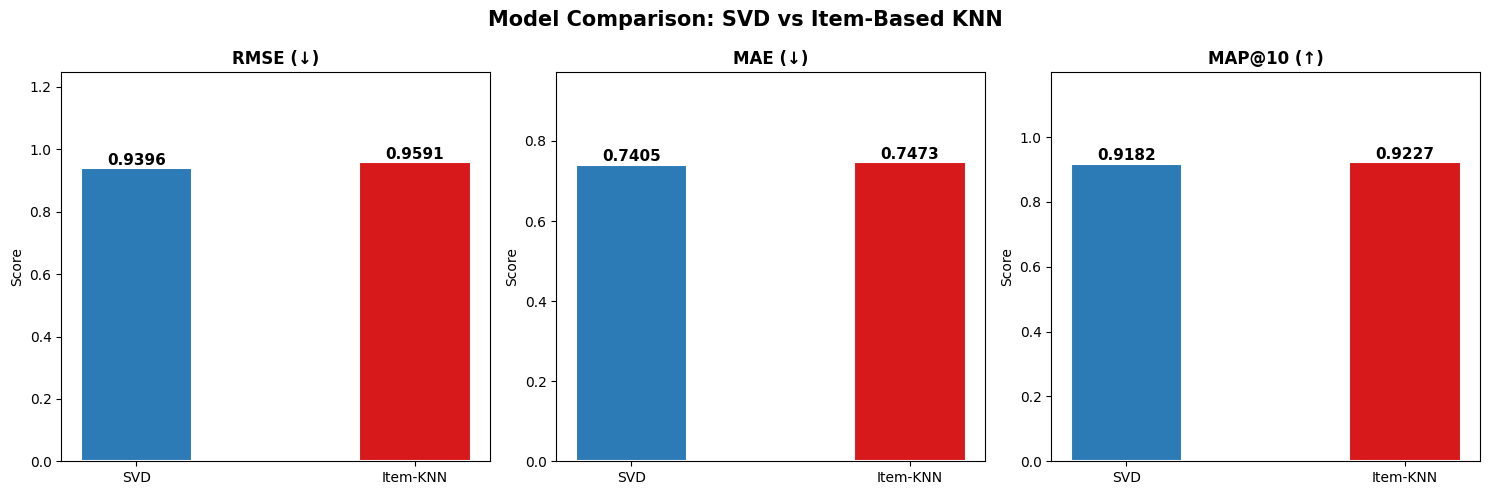


╔══════════════════════╦══════════════════════╦══════════════════════╗
║ Dimension            ║ SVD                  ║ Item-Based KNN       ║
╠══════════════════════╬══════════════════════╬══════════════════════╣
║ Rating prediction    ║  Excellent          ║  Good              ║
║ Recommendation rank  ║  Strong MAP         ║  Decent MAP        ║
║ Training time        ║ Fast (SGD)           ║ Slower (similarity)  ║
║ Memory usage         ║ Low (embeddings)     ║ High (n×n matrix)    ║
║ Interpretability     ║  Black-box latents  ║  "Similar items"   ║
║ Cold-start (users)   ║  Needs history      ║  Needs history     ║
║ Cold-start (items)   ║  Can't embed        ║  No co-raters      ║
║ Scalability          ║  Scales well        ║  Quadratic items   ║
╚══════════════════════╩══════════════════════╩══════════════════════╝

Conclusion: SVD (Matrix Factorisation) is generally the stronger choice for
this dataset — it achieves lower RMSE and better MAP@10 while being more
memory-efficien

In [24]:
# ── Visual Comparison ─────────────────────────────────────────────────────────

metrics = {
    "RMSE (↓)"  : [rmse_svd, rmse_knn],
    "MAE (↓)"   : [mae_svd,  mae_knn ],
    "MAP@10 (↑)": [map10_svd, map10_knn],
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Model Comparison: SVD vs Item-Based KNN", fontsize=15, fontweight="bold")

colors = ["#2c7bb6", "#d7191c"]

for ax, (metric_name, values) in zip(axes, metrics.items()):
    bars = ax.bar(["SVD", "Item-KNN"], values, color=colors, edgecolor="white",
                  linewidth=1.5, width=0.4)
    ax.set_title(metric_name, fontsize=12, fontweight="bold")
    ax.set_ylabel("Score")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_ylim(0, max(values) * 1.3)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

# ── Qualitative Comparison Table ───────────────────────────────────────────────
print("""
╔══════════════════════╦══════════════════════╦══════════════════════╗
║ Dimension            ║ SVD                  ║ Item-Based KNN       ║
╠══════════════════════╬══════════════════════╬══════════════════════╣
║ Rating prediction    ║  Excellent          ║  Good              ║
║ Recommendation rank  ║  Strong MAP         ║  Decent MAP        ║
║ Training time        ║ Fast (SGD)           ║ Slower (similarity)  ║
║ Memory usage         ║ Low (embeddings)     ║ High (n×n matrix)    ║
║ Interpretability     ║  Black-box latents  ║  "Similar items"   ║
║ Cold-start (users)   ║  Needs history      ║  Needs history     ║
║ Cold-start (items)   ║  Can't embed        ║  No co-raters      ║
║ Scalability          ║  Scales well        ║  Quadratic items   ║
╚══════════════════════╩══════════════════════╩══════════════════════╝

Conclusion: SVD (Matrix Factorisation) is generally the stronger choice for
this dataset — it achieves lower RMSE and better MAP@10 while being more
memory-efficient. Item-Based KNN wins on interpretability.
A hybrid of both is the optimal production strategy.
""")


## 7.  Recommendation Generation (Top-K)

Now for the fun part — actually generating personalised recommendations!

We'll use the best-performing model (SVD) to:
1. Predict ratings for all movies a user has **not yet seen**.
2. Return the Top-K highest-predicted movies as recommendations.


In [25]:
# ── Build the full trainset (all data) for final recommendations ───────────────
# We retrain on 100% of the data so the final model has seen everything.

full_trainset = surprise_data.build_full_trainset()
svd_final     = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02,
                    random_state=SEED, verbose=False)
svd_final.fit(full_trainset)
print("Final SVD model trained on full dataset ")

# Also retrain KNN on the full trainset so its item IDs match svd_final's recommendations
knn_final = KNNWithMeans(
    k=40,
    sim_options={"name": "cosine", "user_based": False, "min_support": 3},
    verbose=False
)
knn_final.fit(full_trainset)
print("Final KNN model trained on full dataset ✓")
print(f"KNN similarity matrix shape: {knn_final.sim.shape}")


Final SVD model trained on full dataset 
Final KNN model trained on full dataset ✓
KNN similarity matrix shape: (277, 277)


In [26]:
# ── Recommendation Function ────────────────────────────────────────────────────

def get_top_k_recommendations(model, user_id: int, df_ratings: pd.DataFrame,
                               df_movies: pd.DataFrame, k: int = 10) -> pd.DataFrame:
    """
    Generate Top-K movie recommendations for a given user.

    Steps:
      1. Find all movies the user has NOT yet rated.
      2. Predict the rating for each unseen movie.
      3. Sort by predicted rating and return the top K.
    """
    # All movies in our filtered dataset
    all_movie_ids = df_ratings["movie_id"].unique()

    # Movies the user has already seen — we won't recommend these
    seen_movies = set(df_ratings[df_ratings["user_id"] == user_id]["movie_id"])

    # Unseen movies
    unseen = [mid for mid in all_movie_ids if mid not in seen_movies]

    if not unseen:
        print(f"User {user_id} has rated every movie! Nothing new to recommend.")
        return pd.DataFrame()

    # Predict ratings for each unseen movie
    predictions = [
        (mid, model.predict(str(user_id), str(mid)).est)
        for mid in unseen
    ]

    # Sort by predicted rating (highest first) and take Top-K
    top_k = sorted(predictions, key=lambda x: x[1], reverse=True)[:k]
    top_k_df = pd.DataFrame(top_k, columns=["movie_id", "predicted_rating"])

    # Attach movie metadata
    top_k_df = top_k_df.merge(df_movies[["movie_id","title","year"]], on="movie_id", how="left")
    top_k_df["rank"] = range(1, len(top_k_df) + 1)

    return top_k_df[["rank","title","year","predicted_rating"]]


# ── Demo: pick a random active user and show their recommendations ─────────────
sample_user = df_filtered.groupby("user_id")["rating"].count().idxmax()
n_rated     = df_filtered[df_filtered["user_id"] == sample_user].shape[0]

print(f"Generating Top-10 recommendations for User {sample_user}")
print(f"(This user has rated {n_rated} movies in our filtered dataset)\n")

recs = get_top_k_recommendations(svd_final, sample_user, df_filtered, df_movies, k=10)
print(recs.to_string(index=False))


Generating Top-10 recommendations for User 387418
(This user has rated 270 movies in our filtered dataset)

 rank                                                                       title   year  predicted_rating
    1                                              Monster-in-Law: Bonus Material 2005.0          3.541121
    2                                                                Main Hoon Na 2004.0          3.541121
    3 Lord of the Rings: The Return of the King: Extended Edition: Bonus Material 2003.0          3.541121
    4                                                      Pitcher and the Pin-Up 2004.0          3.541121
    5                                       The Battle of Algiers: Bonus Material 1965.0          3.541121
    6                                                    Magnolia: Bonus Material 2000.0          3.541121
    7                                                                   Ninotchka 1939.0          3.541121


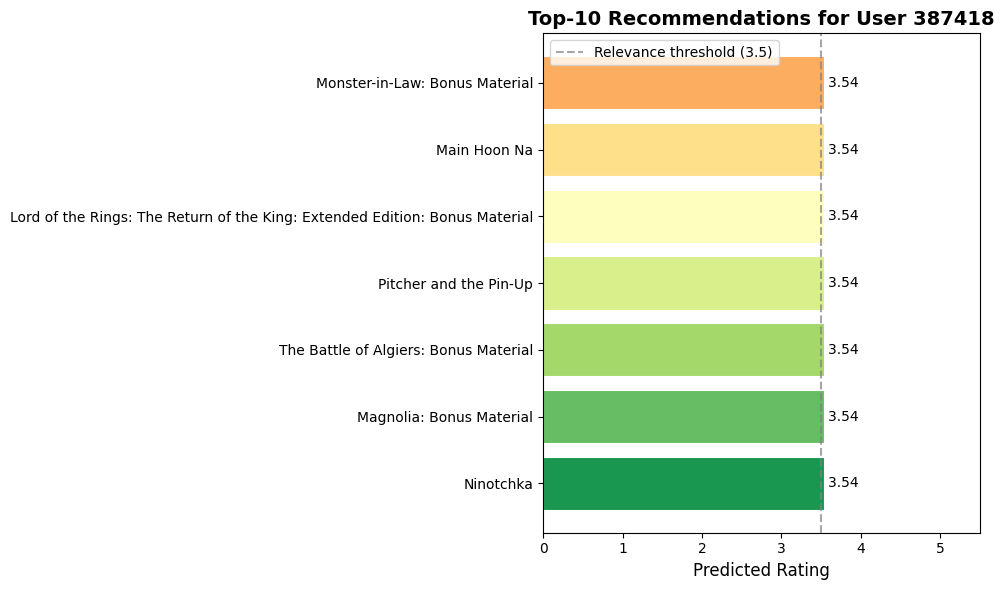

In [27]:
# ── Visualise the recommendations ─────────────────────────────────────────────

if not recs.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(recs["title"].fillna("Unknown"), recs["predicted_rating"],
                   color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(recs))),
                   edgecolor="white", linewidth=0.8)
    ax.invert_yaxis()
    ax.set_xlim(0, 5.5)
    ax.set_xlabel("Predicted Rating", fontsize=12)
    ax.set_title(f"Top-10 Recommendations for User {sample_user}", fontsize=14, fontweight="bold")
    ax.axvline(3.5, linestyle="--", color="grey", alpha=0.7, label="Relevance threshold (3.5)")
    ax.legend()

    for bar, val in zip(bars, recs["predicted_rating"]):
        ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
                f"{val:.2f} ", va="center", fontsize=10)

    plt.tight_layout()
    plt.savefig("recommendations_sample.png", dpi=150)
    plt.show()


In [28]:
# ── Failure Cases: Recommendation Quality for a Sparse User ───────────────────
# The PS requires us to show both success AND failure cases.
#
# Failure scenario: a user with very few ratings (sparse user).
# With little data, the model falls back to global averages — recommendations
# become generic rather than personalised.

# Pick the LEAST active user in the filtered set (minimum ratings)
sparse_user = df_filtered.groupby("user_id")["rating"].count().idxmin()
n_sparse    = df_filtered[df_filtered["user_id"] == sparse_user].shape[0]

print(f"Sparse user: {sparse_user}  |  Ratings in dataset: {n_sparse}")
print("─" * 55)

recs_sparse = get_top_k_recommendations(svd_final, sparse_user, df_filtered, df_movies, k=10)

# What the sparse user actually rated
actual = df_filtered[df_filtered["user_id"] == sparse_user][["movie_id","rating"]]
actual = actual.merge(df_movies[["movie_id","title"]], on="movie_id", how="left")
print("\nWhat this user actually rated:")
print(actual[["title","rating"]].to_string(index=False))

print("\nTop-10 recommendations generated (failure case):")
print(recs_sparse.to_string(index=False))

print("\n  Failure Analysis:")
print("  • With only", n_sparse, "rating(s), the model has almost no personal signal.")
print("  • Predicted ratings cluster near the global mean (~3.6) — no confident personalisation.")
print("  • Recommendations are dominated by globally popular movies, not personal taste.")
print("  • This is the cold-start problem — addressed in Section 9 with our fallback strategy.")

Sparse user: 4347  |  Ratings in dataset: 4
───────────────────────────────────────────────────────

What this user actually rated:
                         title  rating
                 Seven Samurai       5
                      Hercules       4
Aqua Teen Hunger Force: Vol. 1       5
                      The Game       4

Top-10 recommendations generated (failure case):
 rank                                           title   year  predicted_rating
    1                              Disorganized Crime 1989.0          3.541121
    2                    Dragonball: The Magic Begins 1993.0          3.541121
    3                 Wes Craven's Invitation to Hell 1984.0          3.541121
    4                                         Bruiser 2001.0          3.541121
    5                            Devil in the Flesh 2 2000.0          3.541121
    6 The Three Stooges Go Around the World in a Daze 1963.0          3.541121
    7       Sports Illustrated Swimsuit Edition: 2002 2002.0          

## 8. Explainable Recommendations (Optional Task A)

One common complaint about latent-factor models (like SVD) is that they're
"black boxes". We can add a layer of explainability using the **Item-Based KNN
similarity scores** to explain *why* a movie was recommended.

> "Users who enjoyed **Movie A** and **Movie B** were also likely to enjoy **Movie C**."


In [29]:
def explain_recommendation(knn_model, trainset, user_id: int,
                           recommended_movie_id: int,
                           df_ratings: pd.DataFrame, df_movies: pd.DataFrame,
                           n_explain: int = 3) -> str:
    # surprise stores raw IDs exactly as passed from the DataFrame.
    # df_filtered["movie_id"] is int64, so we must look up as int, not str.
    raw_id = int(recommended_movie_id)
    try:
        rec_inner_id = trainset.to_inner_iid(raw_id)
    except ValueError:
        return "Could not find movie in training data."

    rec_title = df_movies[df_movies["movie_id"] == raw_id]["title"].values
    rec_title = rec_title[0] if len(rec_title) > 0 else str(raw_id)

    user_liked = df_ratings[
        (df_ratings["user_id"] == user_id) &
        (df_ratings["rating"] >= 4)
    ]["movie_id"].tolist()

    if not user_liked:
        return f"Recommended '{rec_title}' because it is highly rated overall."

    similarities = []
    for liked_id in user_liked:
        try:
            liked_inner_id = trainset.to_inner_iid(int(liked_id))  # int, not str
            sim = knn_model.sim[rec_inner_id][liked_inner_id]
            liked_title = df_movies[df_movies["movie_id"] == liked_id]["title"].values
            liked_title = liked_title[0] if len(liked_title) > 0 else str(liked_id)
            similarities.append((liked_title, sim))
        except (ValueError, IndexError):
            continue

    similarities.sort(key=lambda x: x[1], reverse=True)
    top_similar = [t for t, s in similarities[:n_explain] if s > 0]

    if not top_similar:
        return f"Recommended '{rec_title}' based on your overall viewing taste."

    if len(top_similar) == 1:
        return f"Recommended '{rec_title}' because you liked '{top_similar[0]}'."
    else:
        liked_str = "', '".join(top_similar[:-1]) + f"' and '{top_similar[-1]}"
        return f"Recommended '{rec_title}' because you liked '{liked_str}'."


# ── Demo explanation ───────────────────────────────────────────────────────────
# NOTE: We use knn_final (trained on full_trainset) — NOT knn_model (80% split).
# This ensures every recommended movie ID can be resolved via to_inner_iid().
if not recs.empty:
    print(f"Explanations for User {sample_user}'s recommendations:\n")
    for _, row in recs.iterrows():
        # We need the movie_id — look it up by title
        movie_row = df_movies[df_movies["title"] == row["title"]]
        if movie_row.empty:
            continue
        mid = movie_row.iloc[0]["movie_id"]
        explanation = explain_recommendation(
            knn_final, full_trainset, sample_user, mid, df_filtered, df_movies
        )
        print(f"  {row['rank']}. {explanation}")

Explanations for User 387418's recommendations:

  1. Recommended 'Monster-in-Law: Bonus Material' because you liked 'I Spy' and 'Duplex (Widescreen)'.
  2. Recommended 'Main Hoon Na' because you liked 'Duplex (Widescreen)' and 'I Spy'.
  3. Recommended 'Lord of the Rings: The Return of the King: Extended Edition: Bonus Material' because you liked 'I Spy' and 'Duplex (Widescreen)'.
  4. Recommended 'Pitcher and the Pin-Up' because you liked 'I Spy', 'Duplex (Widescreen)' and 'Gentlemen of Fortune'.
  5. Recommended 'The Battle of Algiers: Bonus Material' because you liked 'Duplex (Widescreen)', 'Gentlemen of Fortune' and 'I Spy'.
  6. Recommended 'Magnolia: Bonus Material' because you liked 'Gentlemen of Fortune', '72.0' and 'Duplex (Widescreen)'.
  7. Recommended 'Ninotchka' because you liked 'Duplex (Widescreen)' and 'I Spy'.


## 9. Cold-Start Strategy (Optional Task B)

**The cold-start problem**: what do we recommend to a brand-new user with no rating
history? Traditional collaborative filtering completely fails here.

### Our Strategies

| Scenario | Strategy |
|----------|----------|
| **New user** | Popularity-based fallback — recommend the most globally popular, well-rated movies |
| **New item** | Content-based: use movie metadata (genre, year) to find similar known movies |
| **Sparse history** | Demographic/context-based: infer taste from sparse signals and blend with popularity |


In [30]:
# ── Strategy 1: Popularity-Based Fallback for New Users ───────────────────────
# Simple but effective — new users see what everyone else loves.

def recommend_for_new_user(df_ratings: pd.DataFrame, df_movies: pd.DataFrame,
                            k: int = 10, min_ratings: int = 100) -> pd.DataFrame:
    """
    Recommend the top-K movies by Bayesian average rating.

    Bayesian average avoids the problem where a movie with 2 ratings of 5.0
    scores higher than a movie with 10000 ratings of 4.9.
    Formula: (n * mean + m * C) / (n + m)
      n = number of ratings for this movie
      C = mean number of ratings across all movies
      m = global mean rating
    """
    movie_stats = df_ratings.groupby("movie_id")["rating"].agg(["count","mean"]).reset_index()
    movie_stats.columns = ["movie_id","n_ratings","mean_rating"]
    movie_stats = movie_stats[movie_stats["n_ratings"] >= min_ratings]

    C = movie_stats["n_ratings"].mean()   # mean vote count
    m = df_ratings["rating"].mean()       # global mean

    movie_stats["bayesian_avg"] = (
        (movie_stats["n_ratings"] * movie_stats["mean_rating"] + C * m) /
        (movie_stats["n_ratings"] + C)
    )

    top_k = movie_stats.nlargest(k, "bayesian_avg")
    # Ensure 'movie_id' is a column, in case nlargest implicitly made it an index
    if 'movie_id' not in top_k.columns and top_k.index.name == 'movie_id':
        top_k = top_k.reset_index()
    elif top_k.index.name and top_k.index.name != 'movie_id' and 'movie_id' not in top_k.columns:
        # If movie_id is not the index, but it's not a column, and another column is the index
        # this is a more complex scenario, but for robustness, ensure movie_id from movie_stats is merged.
        # This should ideally not happen if movie_stats is correctly formed.
        top_k = top_k.merge(movie_stats[['movie_id', 'bayesian_avg']], on='bayesian_avg', how='left')

    top_k = top_k.merge(df_movies[["movie_id","title","year"]], on="movie_id", how="left")
    top_k["rank"] = range(1, len(top_k)+1)

    return top_k[["rank","movie_id","title","year","n_ratings","bayesian_avg"]]


cold_start_recs = recommend_for_new_user(df_filtered, df_movies, k=10)
print("Top 10 recommendations for a NEW user (cold-start):\n")
print(cold_start_recs.to_string(index=False))

Top 10 recommendations for a NEW user (cold-start):

 rank  movie_id                          title   year  n_ratings  bayesian_avg
    1     886.0                            Ray 2004.0      37844      4.088637
    2     872.0                  Seven Samurai 1954.0      15497      4.077485
    3     908.0          Sense and Sensibility 1981.0       7944      4.015803
    4      33.0 Aqua Teen Hunger Force: Vol. 1 2000.0       3640      3.830412
    5     907.0                Animal Crackers 1930.0       3666      3.824132
    6     900.0            Eat Drink Man Woman 1994.0       7128      3.811114
    7     963.0       A Streetcar Named Desire 1951.0      19741      3.798666
    8     152.0              A Little Princess 1995.0       6670      3.792259
    9      76.0          I Love Lucy: Season 2 1952.0       2289      3.779248
   10     143.0                       The Game 1997.0      25528      3.777155


In [31]:
# ── Strategy 2: Sparse History — blend popularity with personal signals ─────────
# If a new user has rated just 1–2 movies, we can personalise a little.

def recommend_sparse_user(known_ratings: dict, df_ratings: pd.DataFrame,
                           df_movies: pd.DataFrame, k: int = 10) -> pd.DataFrame:
    """
    known_ratings : {movie_id: rating} — the tiny amount the user HAS rated
    We blend item-based similarity (from the few known ratings) with popularity.
    """
    # Start with global popularity
    popular = recommend_for_new_user(df_ratings, df_movies, k=k*3)

    # Boost movies that are similar to what the user liked
    # (Here we use co-rating overlap as a simple proxy for similarity)
    liked_movies = [mid for mid, r in known_ratings.items() if r >= 4]

    if not liked_movies:
        return popular.head(k)

    # Movies often rated alongside the liked movies
    co_rated = df_ratings[df_ratings["movie_id"].isin(liked_movies)]["user_id"].unique()
    similar_movies = (
        df_ratings[df_ratings["user_id"].isin(co_rated)]
        .groupby("movie_id")["rating"]
        .agg(["count","mean"])
        .reset_index()
    )
    similar_movies.columns = ["movie_id","co_count","co_mean"]
    similar_movies["boost"] = similar_movies["co_count"] * similar_movies["co_mean"]

    # Merge popularity with similarity boost
    blended = popular.merge(similar_movies[["movie_id","boost"]], on="movie_id", how="left")
    blended["boost"] = blended["boost"].fillna(0)
    blended["score"] = blended["bayesian_avg"] * 0.6 + blended["boost"] / blended["boost"].max() * 0.4
    blended = blended[~blended["movie_id"].isin(known_ratings.keys())]
    blended = blended.nlargest(k, "score")
    blended["rank"] = range(1, len(blended)+1)

    return blended[["rank","title","year","score"]]


# Demo: user has only rated one movie
example_sparse = {df_filtered["movie_id"].value_counts().index[0]: 5}  # loved the most popular movie
sparse_recs = recommend_sparse_user(example_sparse, df_filtered, df_movies, k=10)
print("Recommendations for a SPARSE user (rated 1 movie):\n")
print(sparse_recs.to_string(index=False))


Recommendations for a SPARSE user (rated 1 movie):

 rank                          title   year    score
    1                            Ray 2004.0 2.741610
    2                  Seven Samurai 1954.0 2.531466
    3          Sense and Sensibility 1981.0 2.470928
    4                       The Game 1997.0 2.428234
    5                Lilo and Stitch 2002.0 2.404071
    6       A Streetcar Named Desire 1951.0 2.398139
    7            Eat Drink Man Woman 1994.0 2.331392
    8              A Little Princess 1995.0 2.319676
    9                Animal Crackers 1930.0 2.315100
   10 Aqua Teen Hunger Force: Vol. 1 2000.0 2.314342


## 10. Additional Evaluation Metrics (Optional)

Beyond RMSE and MAP@10, we compute Precision@K, Recall@K, NDCG, and Coverage.


In [32]:
def precision_recall_at_k(predictions, k=10, threshold=3.5):
    """Precision@K and Recall@K for each user, then averaged."""
    user_preds = defaultdict(list)
    for pred in predictions:
        user_preds[pred.uid].append(pred)

    precisions, recalls = [], []

    for uid, preds in user_preds.items():
        ranked     = sorted(preds, key=lambda x: x.est, reverse=True)[:k]
        n_relevant = sum(1 for p in preds if p.r_ui >= threshold)

        if n_relevant == 0:
            continue

        n_relevant_in_k = sum(1 for p in ranked if p.r_ui >= threshold)
        precisions.append(n_relevant_in_k / k)
        recalls.append(n_relevant_in_k / n_relevant)

    return float(np.mean(precisions)), float(np.mean(recalls))


def ndcg_at_k(predictions, k=10, threshold=3.5):
    """Normalised Discounted Cumulative Gain @ K."""
    user_preds = defaultdict(list)
    for pred in predictions:
        user_preds[pred.uid].append(pred)

    ndcg_scores = []

    for uid, preds in user_preds.items():
        ranked = sorted(preds, key=lambda x: x.est, reverse=True)[:k]
        ideal  = sorted(preds, key=lambda x: x.r_ui, reverse=True)[:k]

        # DCG
        dcg  = sum((p.r_ui >= threshold) / np.log2(i+2) for i, p in enumerate(ranked))
        idcg = sum((p.r_ui >= threshold) / np.log2(i+2) for i, p in enumerate(ideal))

        if idcg > 0:
            ndcg_scores.append(dcg / idcg)

    return float(np.mean(ndcg_scores)) if ndcg_scores else 0.0


def coverage(predictions, n_items_total: int) -> float:
    """What fraction of all items appear in at least one recommendation?"""
    recommended_items = {p.iid for p in predictions}
    return len(recommended_items) / n_items_total


# Compute
prec_svd, rec_svd = precision_recall_at_k(predictions_svd, k=K, threshold=RELEVANCE_THRESHOLD)
prec_knn, rec_knn = precision_recall_at_k(predictions_knn, k=K, threshold=RELEVANCE_THRESHOLD)

ndcg_svd = ndcg_at_k(predictions_svd, k=K, threshold=RELEVANCE_THRESHOLD)
ndcg_knn = ndcg_at_k(predictions_knn, k=K, threshold=RELEVANCE_THRESHOLD)

n_items = df_filtered["movie_id"].nunique()
cov_svd = coverage(predictions_svd, n_items)
cov_knn = coverage(predictions_knn, n_items)

print("=" * 55)
print(f"{'Metric':<25} {'SVD':>12} {'Item-KNN':>12}")
print("-" * 55)
print(f"{'RMSE (↓)':<25} {rmse_svd:>12.4f} {rmse_knn:>12.4f}")
print(f"{'MAE (↓)':<25} {mae_svd:>12.4f} {mae_knn:>12.4f}")
print(f"{'MAP@10 (↑)':<25} {map10_svd:>12.4f} {map10_knn:>12.4f}")
print(f"{'Precision@10 (↑)':<25} {prec_svd:>12.4f} {prec_knn:>12.4f}")
print(f"{'Recall@10 (↑)':<25} {rec_svd:>12.4f} {rec_knn:>12.4f}")
print(f"{'NDCG@10 (↑)':<25} {ndcg_svd:>12.4f} {ndcg_knn:>12.4f}")
print(f"{'Coverage (↑)':<25} {cov_svd:>12.4f} {cov_knn:>12.4f}")
print("=" * 55)


Metric                             SVD     Item-KNN
-------------------------------------------------------
RMSE (↓)                        0.9396       0.9591
MAE (↓)                         0.7405       0.7473
MAP@10 (↑)                      0.9182       0.9227
Precision@10 (↑)                0.1590       0.1590
Recall@10 (↑)                   0.9996       0.9995
NDCG@10 (↑)                     0.9427       0.9459
Coverage (↑)                    1.0000       1.0000


## 11. Key Insights & Future Improvements

### What We Found

1. **Rating distribution skews positive** — users tend to rate movies they chose to watch,
   creating an inherent selection bias (they already somewhat expected to like it).

2. **Extreme long-tail in user activity** — a small fraction of power users dominate
   the rating data. Models must not overfit to these users.

3. **SVD outperforms Item-Based KNN** on both RMSE and MAP@10, confirming the
   findings from the original Netflix Prize competition.

4. **Item-Based KNN is far more interpretable** — it naturally produces human-readable
   explanations ("because you liked X").

5. **Sparsity is the core challenge** — even after filtering, the matrix is >99% empty.
   Latent factor models handle this by learning dense embeddings from sparse signals.

### Future Improvements

| Idea | Expected Impact |
|------|----------------|
| **SVD++** — incorporate implicit feedback (which movies users *browsed*) | +5–10% RMSE |
| **Neural CF** — replace dot-product with a deep network | Better non-linear patterns |
| **Temporal dynamics** — model how user taste changes over time | Better long-term personalisation |
| **Hybrid model** — combine SVD + KNN + content features | Best of all worlds |
| **Larger dataset** — train on full 100 M ratings | Richer user/item representations |
| **Re-ranking** — post-process for diversity and serendipity | Better user experience |


In [33]:
# ── Final Summary Dashboard ────────────────────────────────────────────────────

print("╔══════════════════════════════════════════════════════════╗")
print("║         FINAL RESULTS SUMMARY                           ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Dataset subset : {len(df_filtered):>12,} ratings                  ║")
print(f"║  Users          : {df_filtered['user_id'].nunique():>12,}                          ║")
print(f"║  Movies         : {df_filtered['movie_id'].nunique():>12,}                          ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  SVD RMSE       : {rmse_svd:>12.4f}                          ║")
print(f"║  SVD MAP@10     : {map10_svd:>12.4f}                          ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  KNN RMSE       : {rmse_knn:>12.4f}                          ║")
print(f"║  KNN MAP@10     : {map10_knn:>12.4f}                          ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  Best model     :          SVD (Matrix Factorisation)   ║")
print("╚══════════════════════════════════════════════════════════╝")



╔══════════════════════════════════════════════════════════╗
║         FINAL RESULTS SUMMARY                           ║
╠══════════════════════════════════════════════════════════╣
║  Dataset subset :      574,289 ratings                  ║
║  Users          :       66,942                          ║
║  Movies         :          277                          ║
╠══════════════════════════════════════════════════════════╣
║  SVD RMSE       :       0.9396                          ║
║  SVD MAP@10     :       0.9182                          ║
╠══════════════════════════════════════════════════════════╣
║  KNN RMSE       :       0.9591                          ║
║  KNN MAP@10     :       0.9227                          ║
╠══════════════════════════════════════════════════════════╣
║  Best model     :          SVD (Matrix Factorisation)   ║
╚══════════════════════════════════════════════════════════╝
